### Tutorial A6: Saliency (Input &times; Gradient)

> predict + one backward pass

Attribution methods answer the question "which nucleotides in this sequence drive the model's prediction?" tangermeme implements three of them, and they trade accuracy against cost in different ways.

[DeepLIFT/SHAP](Tutorial_A3_Deep_LIFT_SHAP.ipynb) differences the sequence against a set of shuffled references and propagates that difference back through the network with custom rules for each non-linearity. [Saturation mutagenesis](Tutorial_B4_Saturation_Mutagenesis.ipynb) makes no assumptions at all: it substitutes every base at every position and runs the model forward each time.

<i>Saliency</i>, sometimes called input &times; gradient, is the cheapest of the three. It takes the gradient of the model's output with respect to the one-hot input and multiplies it by that input, which projects the gradient onto the bases that are actually present. That is a single backward pass for a whole batch, and no references, no custom rules, and no perturbations.

The price is the linearity assumption. A gradient is the tangent to the model at the observed sequence, so it describes what would happen if a base were made infinitesimally more or less present, not what happens when it is actually swapped for another base. Gradients also <i>saturate</i>: once a model is confident about a nucleotide, moving it slightly makes little difference and the gradient shrinks toward zero even though the base is essential. We will see that happen below.

Use saliency when you have far more sequences than the other two methods can afford, when your model uses an op that has no DeepLIFT rule registered, or as the inner attribution step of a method that calls attribution many times &mdash; which is exactly what [dependency maps](Tutorial_B8_Dependency_Maps.ipynb) do.

In [1]:
import torch
from model import Beluga

model = Beluga()
model.load_state_dict(torch.load("deepsea.beluga.torch", weights_only=False))

<All keys matched successfully>

As in the other tutorials we will use Beluga, which takes 2,000bp of sequence and predicts 2,002 epigenetic tracks. We need a sequence to attribute, so we pull one from the human genome. You will need to download the hg38 fasta file from https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz and unzip it to run the rest of this notebook yourself.

In [2]:
import pyfaidx
from tangermeme.utils import one_hot_encode

seq = pyfaidx.Fasta("hg38.fa")['chr1'][28328000:28328000+2000].seq.upper()
X = one_hot_encode(seq).unsqueeze(0).float()
X.shape

torch.Size([1, 4, 2000])

#### Basic Usage

`saliency` has the same signature as `deep_lift_shap`: pass it a model, a batch of one-hot encoded sequences, and the index of the output you want to attribute. It returns attributions with exactly the same shape as the input.

In [3]:
from tangermeme.saliency import saliency

X_attr = saliency(model, X, target=214, device='cpu')
X_attr.shape

torch.Size([1, 4, 2000])

The returned values are <i>signed</i>, and every position that is not the observed character is zero, because the gradient has been multiplied by the one-hot input. This is the same convention that `deep_lift_shap` and `saturation_mutagenesis` use, so the result plots directly with `plot_logo`.

In [4]:
X_attr[0, :, 950:955]

tensor([[ 0.0000,  0.0000,  0.0000, -0.0000,  0.0000],
        [-0.0000, -0.0000,  0.0060,  0.0000, -0.0000],
        [ 0.0000, -0.0000,  0.0000,  0.0035,  0.0154],
        [-0.0108,  0.0098, -0.0000, -0.0000, -0.0000]])

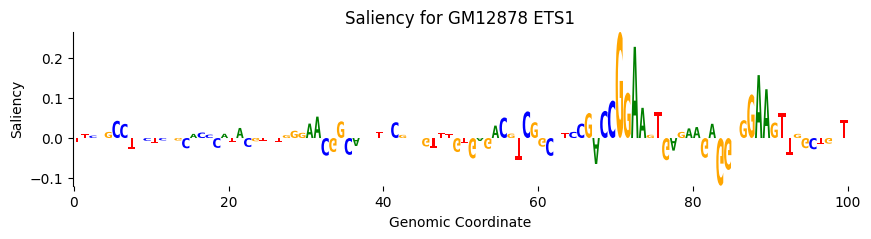

In [5]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
from matplotlib import pyplot as plt
from tangermeme.plot import plot_logo

plt.figure(figsize=(10, 2))
ax = plt.subplot(111)
plot_logo(X_attr[0, :, 950:1050], ax=ax)

plt.xlabel("Genomic Coordinate")
plt.ylabel("Saliency")
plt.title("Saliency for GM12878 ETS1")
plt.show()

#### Hypothetical attributions

By default the gradient is projected onto the observed bases. Passing `hypothetical=True` returns the raw gradient instead, giving a value for every character at every position &mdash; the same idea as `hypothetical=True` in `deep_lift_shap`, and what you want when building contribution-weighted matrices.

There is a subtlety worth keeping in mind. A hypothetical <i>saliency</i> value is the effect of infinitesimally adding a character that is not there, evaluated at the current sequence. It is not the effect of actually substituting that character in. If you need the latter, that is what `saturation_mutagenesis` measures.

In [6]:
X_attr_hypothetical = saliency(model, X, target=214, hypothetical=True, device='cpu')
X_attr_hypothetical[0, :, 950:955]

tensor([[ 0.0165,  0.0207,  0.0075, -0.0084,  0.0162],
        [-0.0239, -0.0085,  0.0060,  0.0068, -0.0245],
        [ 0.0192, -0.0183,  0.0053,  0.0035,  0.0154],
        [-0.0108,  0.0098, -0.0190, -0.0029, -0.0126]])

Projecting the hypothetical values back onto the sequence recovers the default output exactly.

In [7]:
(X_attr_hypothetical * X - X_attr).abs().max()

tensor(0.)

#### How saliency compares to the other two methods

This is the part worth spending time on. Let us compute all three attributions for the same sequence and target, and compare them. We restrict saturation mutagenesis to a 100bp window with `start`/`end`, because running it across all 2,000 positions would mean 6,000 forward passes.

In [8]:
from tangermeme.deep_lift_shap import deep_lift_shap
from tangermeme.saturation_mutagenesis import saturation_mutagenesis

X_attr_dls = deep_lift_shap(model, X, target=214, device='cpu', random_state=0)
X_attr_ism = saturation_mutagenesis(model, X, target=214, start=950, end=1050,
    device='cpu')

X_attr_dls.shape, X_attr_ism.shape

(torch.Size([1, 4, 2000]), torch.Size([1, 4, 100]))

Now we correlate the per-position attributions across that window. Summing over the alphabet axis collapses each method to one value per position, which is the form seqlet calling and most downstream analyses use.

In [9]:
import numpy

sal = X_attr[0, :, 950:1050].sum(dim=0).numpy()
dls = X_attr_dls[0, :, 950:1050].sum(dim=0).numpy()
ism = X_attr_ism[0].sum(dim=0).numpy()

print("saliency vs DeepLIFT/SHAP: %.3f" % numpy.corrcoef(sal, dls)[0, 1])
print("saliency vs ISM:           %.3f" % numpy.corrcoef(sal, ism)[0, 1])
print("DeepLIFT/SHAP vs ISM:      %.3f" % numpy.corrcoef(dls, ism)[0, 1])

saliency vs DeepLIFT/SHAP: 0.744
saliency vs ISM:           0.820
DeepLIFT/SHAP vs ISM:      0.874


All three broadly agree about where the signal is, but not equally: DeepLIFT/SHAP and ISM agree with each other more closely than either agrees with saliency. That gap is the linearity assumption showing up. Saliency is a usable approximation here, not a replacement.

Plotting the three together shows the same thing &mdash; the large peaks appear in all three tracks, and the disagreement is in their relative heights.

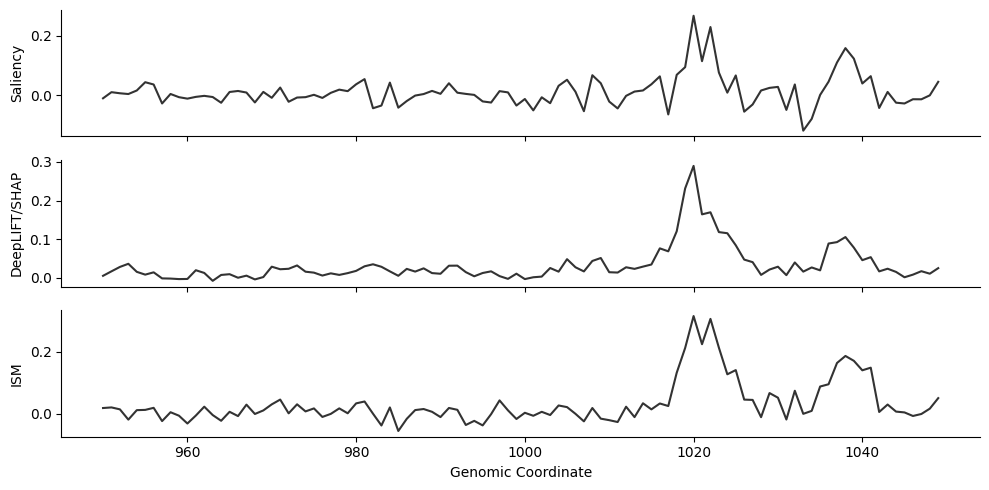

In [10]:
fig, axs = plt.subplots(3, 1, figsize=(10, 5), sharex=True)

for ax, values, name in zip(axs, [sal, dls, ism],
        ["Saliency", "DeepLIFT/SHAP", "ISM"]):
    ax.plot(numpy.arange(950, 1050), values, color='0.2')
    ax.set_ylabel(name)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axs[-1].set_xlabel("Genomic Coordinate")
plt.tight_layout()
plt.show()

#### Where saliency breaks down

The agreement above holds because target 214 is a track the model has real signal for at this locus. Attribute a target the model has nothing to say about and the three methods decorrelate, because they are all describing noise. Target 267 at this same locus is one such case.

In [11]:
for target in [214, 267]:
    sal = saliency(model, X, target=target, device='cpu')[0, :, 950:1050]
    dls = deep_lift_shap(model, X, target=target, device='cpu',
        random_state=0)[0, :, 950:1050]

    r = numpy.corrcoef(sal.sum(dim=0).numpy(), dls.sum(dim=0).numpy())[0, 1]
    print("target %d: saliency vs DeepLIFT/SHAP = %+.3f" % (target, r))

target 214: saliency vs DeepLIFT/SHAP = +0.744


target 267: saliency vs DeepLIFT/SHAP = -0.222


This is worth checking before you trust a saliency track: if it disagrees with a DeepLIFT/SHAP run on a handful of sequences, that is a signal to spend the extra compute rather than to explain the difference away.

#### So why use it?

Because it is fast, and because the cost of the other two grows in ways that saliency's does not. DeepLIFT/SHAP runs the model once per example-reference pair, so it scales with `n_shuffles`; ISM runs it once per single-base edit, so it scales with the length of the window. Saliency is one forward and one backward pass per batch, regardless.

Let us time all three on the same sequence.

In [12]:
import time

t0 = time.time()
saliency(model, X, target=214, device='cpu')
t_sal = time.time() - t0

t0 = time.time()
deep_lift_shap(model, X, target=214, n_shuffles=20, device='cpu', random_state=0)
t_dls = time.time() - t0

t0 = time.time()
saturation_mutagenesis(model, X, target=214, start=950, end=1050, device='cpu')
t_ism = time.time() - t0

print("saliency:                %.2fs" % t_sal)
print("DeepLIFT/SHAP (20 refs): %.2fs" % t_dls)
print("ISM (100bp window):      %.2fs" % t_ism)

saliency:                2.37s
DeepLIFT/SHAP (20 refs): 8.55s
ISM (100bp window):      11.28s


ISM here covers only 5% of the sequence. Attributing the full 2,000bp would cost twenty times as much, whereas saliency has already covered every position.

The practical pattern is triage: run saliency across a very large set of sequences to find the regions worth looking at, then re-attribute just those regions with DeepLIFT/SHAP or ISM. Do not report saliency values as final attributions when you can afford one of the other two.

#### Saliency satisfies the `func=` plug-point

`saliency` takes `(model, X, args=..., **kwargs)`, so it can be handed to any of the perturbation functions in place of `predict` or `deep_lift_shap`. Here we measure how the attributions change when an AP-1 motif is substituted into shuffled backgrounds.

In [13]:
from tangermeme.marginalize import marginalize
from tangermeme.utils import random_one_hot

X_bg = random_one_hot((4, 4, 2000), random_state=0).type(torch.float32)

attr_before, attr_after = marginalize(model, X_bg, "TGACTCATC",
    func=saliency, target=267, device='cpu')

attr_before.shape, attr_after.shape

(torch.Size([4, 4, 2000]), torch.Size([4, 4, 2000]))

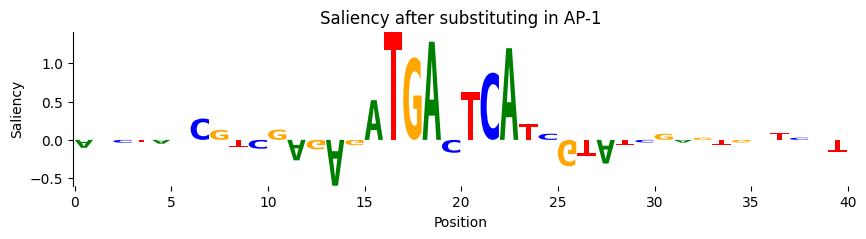

In [14]:
plt.figure(figsize=(10, 2))
ax = plt.subplot(111)
plot_logo(attr_after[0, :, 980:1020], ax=ax)

plt.xlabel("Position")
plt.ylabel("Saliency")
plt.title("Saliency after substituting in AP-1")
plt.show()

#### Things to watch out for

- **Gradient saturation is the headline caveat.** As shown above, saliency can disagree substantially with DeepLIFT/SHAP and ISM on real sequence. Prefer one of the other two whenever you can afford it.
- **`target` indexes the second dimension of the model output.** Your model must return a `(batch_size, n_targets)` tensor. If it returns a profile of shape `(batch_size, n_tasks, length)`, `target` will silently select an entire task rather than one output. Pass a `func` that reduces the profile, or wrap the model.
- **`func=` here is a post-processing hook**, applied to the model's output before `target` is selected &mdash; the same meaning it has in `predict`, and not the `func(model, X)` plug-point. It runs inside the autograd graph, so it must be differentiable.
- **Attributions come back on the CPU** and in the model's dtype, and your model's original device and training mode are restored after the call.

#### Next steps

Saliency is cheap enough to call thousands of times, which is what makes [dependency maps](Tutorial_B8_Dependency_Maps.ipynb) practical: substitute every base at every position and ask how the attributions <i>elsewhere</i> in the sequence respond.